In [25]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rc
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import glob
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colormaps as cmaps
import matplotlib.lines as mlines


In [26]:
#------------------------------------------------------
#  Paths
#------------------------------------------------------

best_sim_n=200
leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/paleogris_8km.nc")
best=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{best_sim_n}/yelmo2D_reduced.nc")
topo = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
lgm_leg = xr.where((lgm.mask==3)|(lgm.mask==2),1,0)

FileNotFoundError: [Errno 2] No such file or directory: '/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/200/yelmo2D_reduced.nc'

/tmp/ipykernel_3551429/3014350237.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, lim)


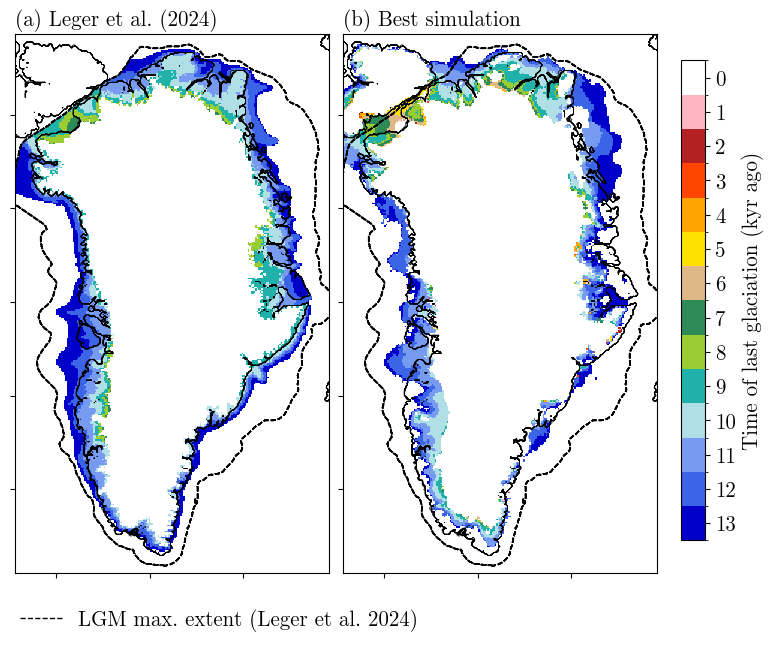

In [27]:
# ----------------------------------------------------------------------------
# Figure comparison best simulation vs Leger et al. (2024)
# ----------------------------------------------------------------------------
f=15
fig,axs=plt.subplots(1,2, figsize=(8,7))
lim=14

cmap_name =	cmaps.amwg_r
# cmap = cm.get_cmap(cmap_name, lim)
cmap = cm.get_cmap(cmap_name, lim)
colors = cmap(np.arange(cmap.N))
colors[0] = [1, 1, 1, 1]
cmap = mcolors.ListedColormap(colors)

levels = np.linspace(-0.5, lim-0.5, lim+1)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

ax=axs[0]
im2 = ax.pcolormesh(leger.xc,leger.yc,leger.age*1e-3, cmap=cmap, norm=norm, shading='auto')
ax.set_title("(a) Leger et al. (2024)", loc="left",fontsize=f)

ax=axs[1]
im2 = ax.pcolormesh(best.xc,best.yc,best.isochrone.where(best.isochrone<=lim-0.5), cmap=cmap, norm=norm, shading='auto')

ax.set_title("(b) Best simulation", loc="left",fontsize=f)

for ax in axs:
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.contour(topo.xc, topo.yc, topo.z_srf, levels=np.arange(0, 11, 1), colors='black', linewidths=0.5)
    im_lgm=ax.contour(lgm.xc, lgm.yc, lgm_leg, colors='black',  linestyles="dashed",linewidths=1)
    ax.set_xlim([topo.xc.min(), topo.xc.max()])
    ax.set_ylim([topo.yc.min(), topo.yc.max()])
    
    
# Legend
gray_line  = mlines.Line2D([], [], color='black', linestyle="dashed", linewidth=1,  label='LGM max. extent (Leger et al. 2024)')
leg = fig.legend(handles=[gray_line],loc='lower left',bbox_to_anchor=(0, 0), frameon=False)

cbar = plt.colorbar(im2, ax=axs, ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13], orientation='vertical')
cbar.ax.set_position([0.85, 0, 0.03, 1])
cbar.set_label("Time of last glaciation (kyr ago)")
cbar.ax.invert_yaxis()
plt.subplots_adjust(left=0,right=0.82,wspace=0)

fig.savefig("../figs/best_isochrones.png", dpi=300)
